# WKBeam–LUKE coupled simulation setup

This notebook creates the `input/` folder for a WKBeam campaign that is driven
by the BOBAFETT/LUKE optimisation loop.  It does **not** create `output/`,
`plots/`, binning configs, or run scripts — those are generated per-iteration
by `wkb_make_configs_ed` and `wkb_setup_dirs_ed` inside MATLAB.

**What gets created**

```
<campaign_root>/
  input/
    topfile, ne.dat, Te.dat, nefluct.dat   ← copied from data_folder
    RayTracing_template.txt                ← geometry + equilibriumdirectory patched;
                                              output_dir / qlabs_* left as placeholders
    fluct_amplitude.py
    Lperp_rhos_model.py
```

**Workflow**

1. Point to the prepared data folder → `load_ec_params` reads the ECparams file,
   `copy_input_files` copies equilibrium files into `input/`
2. Generate `input/RayTracing_template.txt` — geometry comes from ECparams;
   QL-specific fields (`qlabs_maxwellian`, `qlabs_edf_file`, `output_dir`) are
   left as placeholders for `wkb_make_configs_ed` to patch at runtime
3. Generate the scattering model files `fluct_amplitude.py` and `Lperp_rhos_model.py`

In [6]:
import os
import sys
import numpy as np

WKBEAM_DIR = '/home/devlamin/WanKenoBEAM'
if WKBEAM_DIR not in sys.path:
    sys.path.insert(0, WKBEAM_DIR)

from Wrapper.wrapper_aux import SimulationSetup, load_ec_params

## 1 — Campaign definition

Point to the prepared data folder, load the EC launcher parameters, create the
campaign `input/` directory, and copy equilibrium files.

In [7]:
# --- Data source ----------------------------------------------------------
campaign_root = '/home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3'
data_folder   = '/home/devlamin/matlab/wkbeam_input_prep/88612_1.25'
vesselfile    = '/home/devlamin/WanKenoBEAM/Tools/PlotData/PlotVessel/88612_vessel.mat'

shot = 88612
time = 1.25
tag  = 'QLtest_sparse_3'
fluct = False
nrays = 1000

# --- Read EC launcher parameters (one entry per active launcher) ----------
launcher_list = load_ec_params(data_folder)

# --- Tokamak geometry (for SimulationSetup) --------------------------------
rmaj = 88.   # [cm]
rmin = 25.   # [cm]

# --- Single shared campaign directory -------------------------------------
# All launchers share one input/ directory.  MATLAB's waveparam.run_inputPath
# must point to campaign_root.  wkb_make_configs_ed patches per-launcher
# geometry at runtime from each wave struct, so sim_name here is a placeholder.
first_params, first_power, _ = launcher_list[0]
sim = SimulationSetup(
    sim_dir    = campaign_root,
    sim_name   = tag,
    rmaj       = rmaj,
    rmin       = rmin,
    InputPower = first_power,
    tag        = tag,
)
sim.create_input_dir()
sim.copy_input_files(data_folder)

Loaded ECparams: launcher=L4, freq=84.0 GHz, InputPower=0.883 MW
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input
Copied to /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input/: Te.dat, ne.dat, nefluct.dat, topfile


## 2 — RayTracing template

Writes `input/RayTracing_template.txt` using `RayTracing_QLabs.txt` as base.
Launcher geometry and `equilibriumdirectory` are patched now.  
The following fields are left as placeholders for `wkb_make_configs_ed`:
- `output_dir` / `output_filename` → set to `iter_N/output/` at runtime
- `qlabs_maxwellian` → `True` at iter 0, `False` thereafter
- `qlabs_edf_file` → path to the current EDF at runtime

In [8]:
# Use the first active launcher's geometry; values are overridden per-beam
# at runtime by wkb_make_configs_ed — only shared fields (equilibriumdirectory,
# sigma, nmbrRays, scattering, vesselfile) matter in the template.
sim.make_raytracing_template(
    sigma      = -1.,      # mode: -1 = X-mode, +1 = O-mode
    nmbrRays   = nrays,
    vesselfile = vesselfile,
    scattering = fluct,
    **first_params,        # freq, beamwidths, etc. — overridden by MATLAB anyway
)

Generating input/RayTracing_template.txt ...
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input/RayTracing_template.txt


## 3 — Scattering model files

Generate the fluctuation amplitude and perpendicular correlation length Python
files into `input/`.  WKBeam loads these at runtime via the string keys
`'fluct_amplitude'` and `'Lperp_rhos_model'` set in the template.

In [9]:
sim.make_fluct_amplitude(
    ballooning = 0.5,   # 1 = isotropic, 0 = fully ballooned
)
sim.make_lperp_model(
    mu      = 2.0,   # deuterium
    Z       = 1.0,
    epsilon = 0.3,   # minimum Lperp [cm]
    factor  = 7.4,   # Lperp = factor * rho_s  (GBS calibration)
)

  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input/fluct_amplitude.py
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input/Lperp_rhos_model.py


## 4 — Inspect fluct_amplitude profile

Run the generated `fluct_amplitude.py` to visualise the fluctuation amplitude
profile before launching the BOBAFETT optimisation.

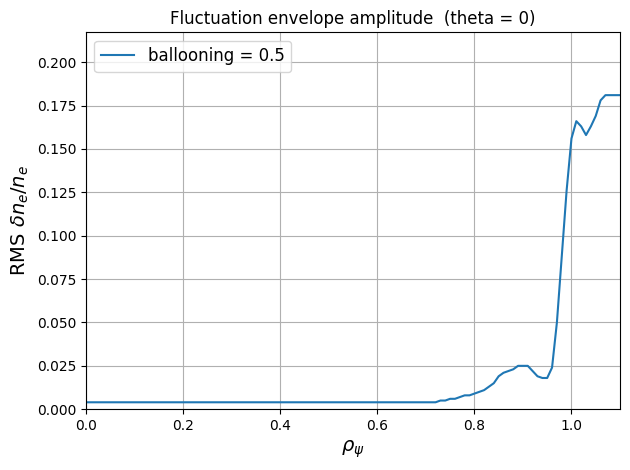

{'__name__': '__main__',
 '__doc__': 'Model for the fluctuation envelope amplitude.\n\nThe fluctuation amplitude is factored into a radial profile (read from\nnefluct.dat in the same directory as this file) and a poloidal ballooning\nenvelope:\n\n    delta_ne/ne(rho, theta) = A_rho(rho) * A_theta(theta)\n\nwhere\n\n    A_theta(theta) = 0.5 * (1 + ballooning + (1 - ballooning) * cos(theta))\n\n    ballooning=1  →  isotropic  (A_theta = 1 everywhere)\n    ballooning=0  →  fully ballooned  (A_theta = cos^2(theta/2))\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse_3/input/fluct_amplitude.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='bu

In [10]:
%matplotlib inline
import runpy

_fluct_path = os.path.join(sim.sim_dir, 'input', 'fluct_amplitude.py')
runpy.run_path(_fluct_path, run_name='__main__')